
# EEG Motor Imagery (MI)
1) Configure → 2) Load (EEGBCI or CSV) → 3) Preprocess → 4) Epoch → 5) TFR (Morlet, % change) → 6) ERD metrics → 7) (Optional) CSP+LDA decoding

**Notes**
- Default uses the PhysioNet EEGBCI dataset (left vs right hand MI).
- You can switch to your own CSV (format described below).
- Plots use Matplotlib only.


In [1]:

# %% Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Make figures a bit larger
plt.rcParams['figure.figsize'] = (9, 4)
mne.set_log_level('WARNING')



## 1) Configure
- `source`: `"eegbci"` or `"csv"`  
- EEGBCI: set `subject` and `runs`  
- CSV: set `csv_path` and (optionally) `channel_cols` and `event_code_map`

**CSV format (expected):**
- Columns: `timestamp` (seconds), `type` (`EEG` or `Marker`), EEG channels (e.g., `ch1...ch16`), `marker` (int codes for events)
- Set `csv_voltage_unit` to `"uV"`, `"mV"`, or `"V"`


In [ ]:

# %% Config
source = "eegbci"   # "eegbci" or "csv"

# EEGBCI settings
subject = 1
runs = [4, 8, 12]  # motor imagery, left vs right

# CSV settings (used if source == "csv")
csv_path = r"D:/path/to/your_file.csv"   # <- change me
time_col = "timestamp"
type_col = "type"          # values: "EEG" or "Marker"
eeg_value = "EEG"
marker_value = "Marker"
marker_col = "marker"      # integer codes
channel_cols = None        # e.g. [f"ch{i}" for i in range(1,17)]
event_code_map = {1: "left", 2: "right"}  # CSV marker code -> name
csv_voltage_unit = "uV"    # "uV" | "mV" | "V"

# Preprocessing
notch_freq = 50.0
l_freq, h_freq = 0.5, 40.0
resample_sfreq = 250.0     # set None to keep native
reref = "average"          # "average" or list of ref channel names

# Epoching
tmin, tmax = -1.0, 4.0
baseline = (-1.0, 0.0)

# TFR (Morlet)
freqs = np.arange(2, 36)   # 2–35 Hz
n_cycles = 7.0
baseline_mode = "percent"  # % change

# ERD metrics
mu_band = (8., 13.)
beta_band = (13., 30.)
erd_onset_threshold = -20.0   # % drop (negative)
mi_window = (1.0, 4.0)        # seconds
sensorimotor_chs = ["C3", "C4", "Cz"]

# Output directory
OUT = Path("outputs"); OUT.mkdir(exist_ok=True, parents=True)
print("Configured. Source =", source)


Configured. Source = eegbci



## 2) Load data
Choose EEGBCI (auto-download via MNE) **or** your own CSV.


In [7]:

# %% Load data
def _to_volts(arr, unit: str):
    u = (unit or '').lower()
    if u in {"uv", "µv"}: return arr / 1e6
    if u in {"mv"}:       return arr / 1e3
    if u in {"v"}:        return arr
    raise ValueError(f"Unknown voltage unit: {unit}")

if source.lower() == "eegbci":
    from mne.datasets import eegbci
    print(f"Fetching EEGBCI s{subject} runs {runs} ...")
    file_paths = eegbci.load_data(subject, runs)
    raws = [mne.io.read_raw_edf(fp, preload=True) for fp in file_paths]
    for r in raws: eegbci.standardize(r)
    raw = mne.concatenate_raws(raws)
    raw.rename_channels(lambda x: x.strip("."))  # remove dots from channel names
    montage = mne.channels.make_standard_montage("standard_1005")
    raw.set_montage(montage, on_missing="ignore")
    events, _ = mne.events_from_annotations(raw, event_id={"T1":1, "T2":2})
    event_id = {"left":1, "right":2}

elif source.lower() == "csv":
    df = pd.read_csv(csv_path, encoding="latin1")
    eeg_df = df[df[type_col] == eeg_value].copy()
    mrk_df = df[df[type_col] == marker_value].copy()
    # channels
    ch_cols = channel_cols
    if ch_cols is None:
        patt = df.columns.str.match(r"^(ch|eeg)\d+$", case=False)
        ch_cols = [c for c, m in zip(df.columns, patt) if m and c in eeg_df.columns]
        if not ch_cols:
            numeric_cols = [c for c in eeg_df.columns if np.issubdtype(eeg_df[c].dtype, np.number)]
            ch_cols = [c for c in numeric_cols if c != time_col]
    # sampling rate
    eeg_df = eeg_df.sort_values(time_col).drop_duplicates(subset=[time_col])
    ts = eeg_df[time_col].to_numpy()
    sfreq = float(np.round(1.0 / np.median(np.diff(ts))))
    data = eeg_df[ch_cols].to_numpy().T
    data = _to_volts(data, csv_voltage_unit)
    info = mne.create_info(ch_names=ch_cols, sfreq=sfreq, ch_types="eeg")
    raw = mne.io.RawArray(data, info)
    try:
        montage = mne.channels.make_standard_montage("standard_1005")
        raw.set_montage(montage, on_missing="ignore")
    except Exception:
        pass
    # events
    mrk_df = mrk_df.sort_values(time_col)
    names = sorted(set(event_code_map.values()))
    name_to_int = {name: i+1 for i, name in enumerate(names)}
    code_to_int = {code: name_to_int[name] for code, name in event_code_map.items()}
    start_time = eeg_df[time_col].iloc[0]
    events = []
    for t, code in zip(mrk_df[time_col].to_numpy(), mrk_df[marker_col].astype(int).to_numpy()):
        sample = int(np.round((t - start_time) * sfreq))
        if 0 <= sample < raw.n_times and code in code_to_int:
            events.append([sample, 0, code_to_int[code]])
    events = np.array(events, dtype=int)
    event_id = name_to_int
else:
    raise ValueError("source must be 'eegbci' or 'csv'")

print(raw)
print("Events:", len(events), "event_id:", event_id)


Fetching EEGBCI s5 runs [4, 8, 12] ...
<RawEDF | S005R04.edf, 64 x 59040 (369.0 s), ~28.9 MiB, data loaded>
Events: 45 event_id: {'left': 1, 'right': 2}



## 3) Preprocess + quick QC
- Notch 50 Hz, band-pass 0.5–40 Hz, optional resample to 250 Hz, average reference  
- Quick 5 s overlay: raw vs filtered (up to 8 channels; prefer C3/C4/Cz)


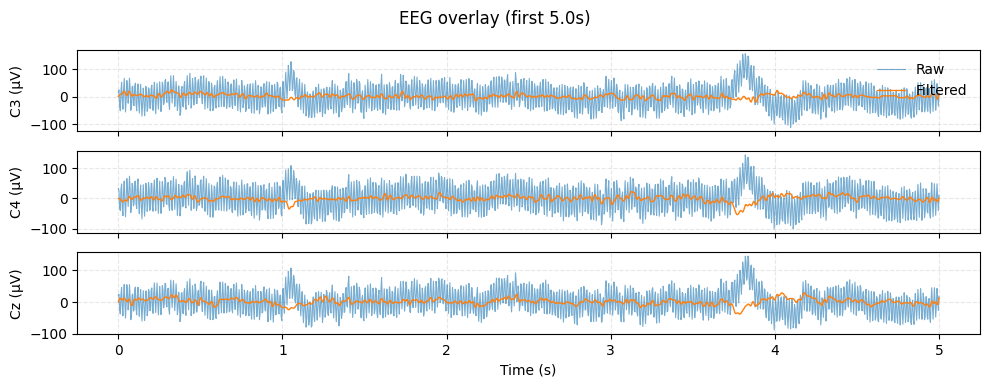

In [8]:

# %% Preprocess + QC
raw_f = raw.copy()
if notch_freq:
    raw_f.notch_filter(freqs=[notch_freq], picks="eeg")
raw_f.filter(l_freq=l_freq, h_freq=h_freq, picks="eeg")
if resample_sfreq is not None and resample_sfreq > 0:
    raw_f.resample(resample_sfreq)
if reref == "average":
    raw_f.set_eeg_reference("average", projection=False)
elif isinstance(reref, (list, tuple)):
    raw_f.set_eeg_reference(reref, projection=False)

# QC overlay plot (first 5 s)
max_channels = 16
pref = [ch for ch in sensorimotor_chs if ch in raw.ch_names and ch in raw_f.ch_names]
chs = (pref or raw_f.ch_names)[:max_channels]

r0 = raw.copy()
r1 = raw_f.copy()
if abs(r0.info['sfreq'] - r1.info['sfreq']) > 1e-6:
    r0.resample(r1.info['sfreq'])
win = (0.0, min(5.0, r0.times[-1], r1.times[-1]))
r0.crop(*win); r1.crop(*win)
p0 = mne.pick_channels(r0.ch_names, include=chs)
p1 = mne.pick_channels(r1.ch_names, include=chs)

t = r1.times
dat0 = (r0.get_data(picks=p0) * 1e6)
dat1 = (r1.get_data(picks=p1) * 1e6)

fig, axes = plt.subplots(len(chs), 1, sharex=True, figsize=(10, max(3, len(chs)*1.3)))
if len(chs) == 1: axes = [axes]
for ax, ch, y0, y1 in zip(axes, chs, dat0, dat1):
    ax.plot(t, y0, label="Raw", alpha=0.6, linewidth=0.8)
    ax.plot(t, y1, label="Filtered", linewidth=1.0)
    ax.set_ylabel(f"{ch} (µV)"); ax.grid(True, linestyle="--", alpha=0.3)
axes[0].legend(loc="upper right", frameon=False)
axes[-1].set_xlabel("Time (s)")
plt.suptitle(f"EEG overlay (first {win[1]-win[0]:.1f}s)"); plt.tight_layout()
plt.show()



## 4) Epoch around events
Baseline: -1…0 s; Epoch: -1…4 s.


<Epochs | 44 events (all good), -1 – 4 s (baseline -1 – 0 s), ~27.0 MiB, data loaded,
 'left': 20
 'right': 24>


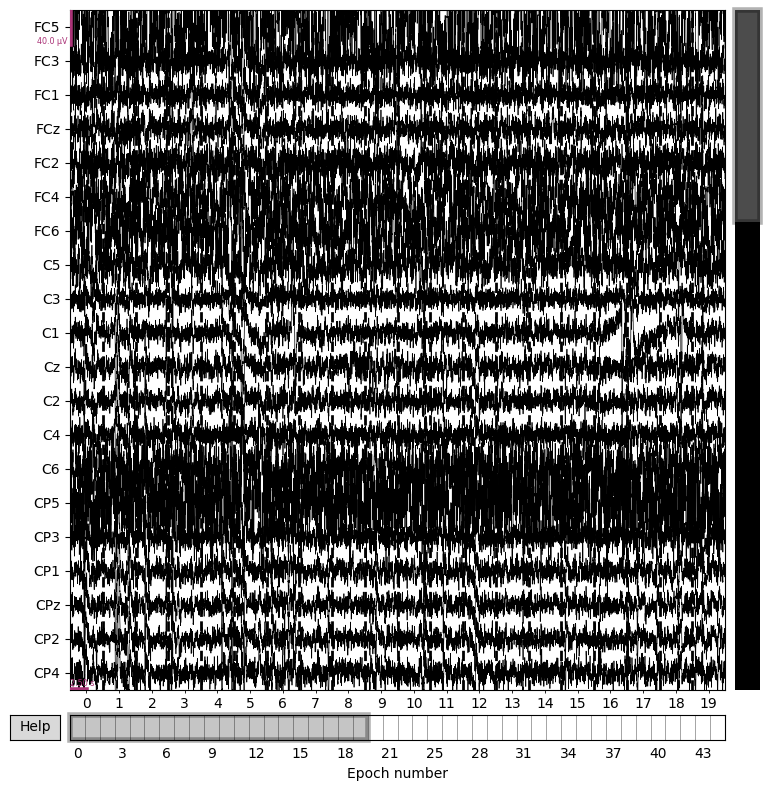

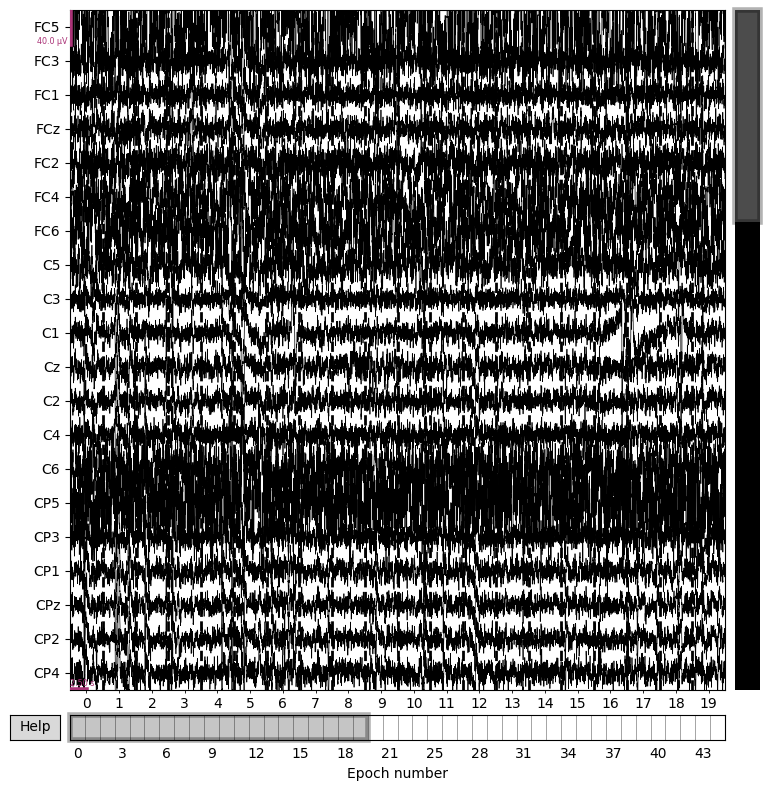

In [12]:

# %% Epoching
picks = mne.pick_types(raw_f.info, eeg=True, exclude='bads')
epochs = mne.Epochs(raw_f, events, event_id=event_id, tmin=tmin, tmax=tmax,
                    baseline=baseline, picks=picks, preload=True, detrend=1)
print(epochs)
epochs.plot(block=False)



## 5) Time–Frequency (Morlet) + baseline (% change)
- ERD = **negative** % change (often blue); ERS = **positive** (often red)  
- Plots below show average across trials.


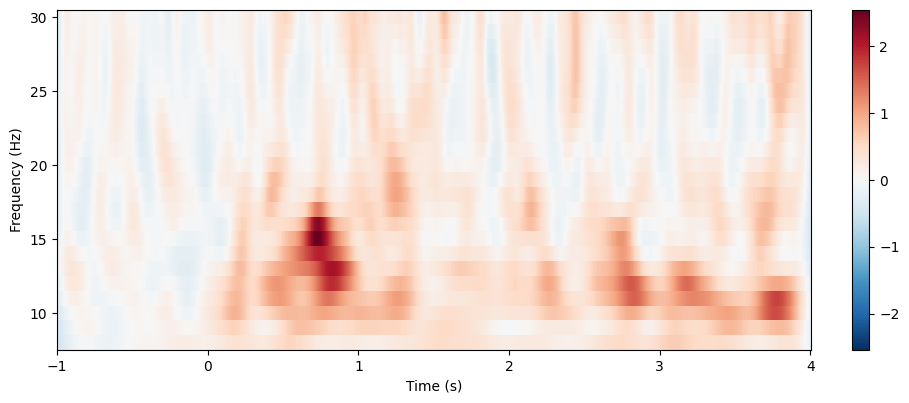

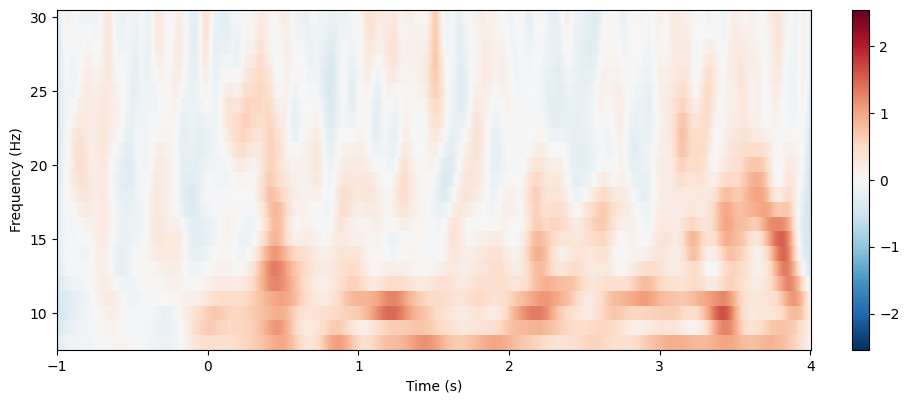

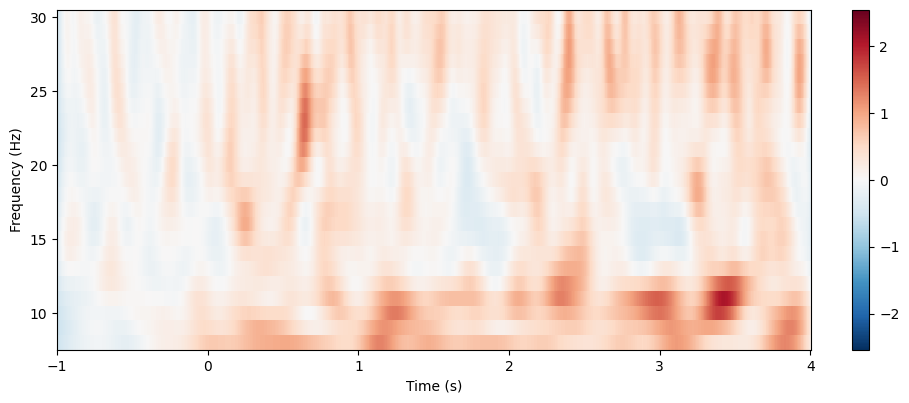

In [13]:

# %% TFR (Morlet)
power_indiv = mne.time_frequency.tfr_morlet(
    epochs, freqs=freqs, n_cycles=n_cycles, use_fft=True,
    return_itc=False, average=False, decim=1, n_jobs=None
)
power_indiv.apply_baseline(baseline, mode=baseline_mode)
power_avg = power_indiv.average()

# Show C3/C4/Cz if available
show_chs = [ch for ch in sensorimotor_chs if ch in power_avg.ch_names] or None
figs = power_avg.plot(picks=show_chs, show=False)
plt.show()



## 6) Simple ERD metrics (mu/beta)
Compute per-trial:
- Peak ERD (% min) in `mi_window`  
- Onset time when drop < `erd_onset_threshold`% sustained for 200 ms


In [ ]:

# %% ERD metrics
freq_arr = power_indiv.freqs
times = power_indiv.times
sfreq = epochs.info['sfreq']

mu_idx = np.where((freq_arr >= mu_band[0]) & (freq_arr <= mu_band[1]))[0]
be_idx = np.where((freq_arr >= beta_band[0]) & (freq_arr <= beta_band[1]))[0]

chs = [c for c in sensorimotor_chs if c in epochs.ch_names] or epochs.ch_names
ch_idx = [epochs.ch_names.index(c) for c in chs]

mi_lo = int(np.round((mi_window[0] - epochs.tmin) * sfreq))
mi_hi = int(np.round((mi_window[1] - epochs.tmin) * sfreq))
sustain = int(np.round(0.2 * sfreq))

rows = []
inv_event = {v:k for k,v in epochs.event_id.items()}

for ei in range(len(epochs)):
    cond = inv_event[epochs.events[ei, 2]]
    for band_name, bidx in [("mu", mu_idx), ("beta", be_idx)]:
        # average over selected channels and freqs
        band_ts = power_indiv.data[ei, ch_idx][:, bidx, :].mean(axis=1).mean(axis=0)
        seg = band_ts[mi_lo:mi_hi]
        peak_erd = float(np.min(seg))

        onset = np.nan
        below = seg < erd_onset_threshold
        if below.any():
            idxs = np.where(below)[0]
            for idx in idxs:
                end = idx + sustain
                if end <= len(seg) and np.all(seg[idx:end] < erd_onset_threshold):
                    onset = times[mi_lo + idx]
                    break

        rows.append(dict(trial=ei, condition=cond, band=band_name,
                         peak_erd_percent=peak_erd, onset_s=onset))

erd_df = pd.DataFrame(rows)
display(erd_df.head())

# quick bar (means)
means = erd_df.groupby(["band","condition"])["peak_erd_percent"].mean().unstack()
means.plot(kind="bar")
plt.ylabel("Peak ERD (%): negative = drop")
plt.title("Peak ERD by band × condition")
plt.tight_layout(); plt.show()



## 7) (Optional) Quick decoding (CSP + LDA)
5-fold CV accuracy on MI window (8–30 Hz).  
Skip if you don't need it.


In [ ]:

# %% Optional decoding
try:
    ep = epochs.copy().crop(*mi_window).load_data().filter(8., 30., picks='eeg')
    X = ep.get_data()              # (n_epochs, n_channels, n_times)
    y = ep.events[:, 2]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pipe = Pipeline([('csp', CSP(n_components=6, reg='oas', log=True, norm_trace=False)),
                     ('lda', LDA())])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    print(f"Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
except Exception as e:
    print("Decoding skipped:", e)



## 8) Save ERD metrics


In [ ]:

# %% Save ERD CSV
out_csv = OUT / "erd_metrics.csv"
erd_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)
